In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../data/car_prices.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


In [3]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [4]:
df = df.drop_duplicates()

In [5]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [6]:
df.shape

(558837, 16)

In [7]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='str')

In [8]:
100- ((558837-63452)/558837)*100

11.354294722790371

In [9]:
df["make"] = df["make"].fillna("Unknown")
df["model"] = df["model"].fillna("Unknown")
df["trim"] = df["trim"].fillna("Unknown")

df["body"] = df["body"].fillna(df["body"].mode()[0])
df["transmission"] = df["transmission"].fillna(df["transmission"].mode()[0])

In [10]:
df = df.drop(columns=['vin', 'trim', 'seller'])

In [11]:
df.isnull().sum()

year                0
make                0
model               0
body                0
transmission        0
state               0
condition       11820
odometer           94
color             749
interior          749
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [12]:
df['condition'] = df['condition'].fillna(df['condition'].median())
df = df.dropna(subset=['odometer'])
df = df.dropna(subset=['sellingprice'])
df = df.dropna(subset=['saledate'])
df['mmr'] = df['mmr'].fillna(df['mmr'].median())
df['color'] = df['color'].fillna('Unknown')
df['interior'] = df['interior'].fillna('Unknown')

## Price vs Mileage

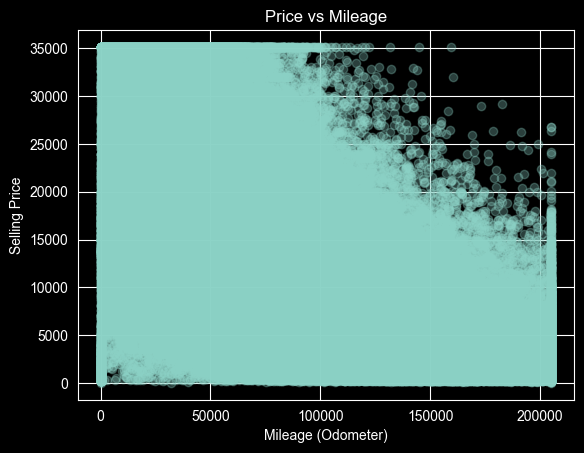

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df['odometer'], df['sellingprice'], alpha=0.3)
plt.xlabel("Mileage (Odometer)")
plt.ylabel("Selling Price")
plt.title("Price vs Mileage")
plt.show()

## Condition vs Price

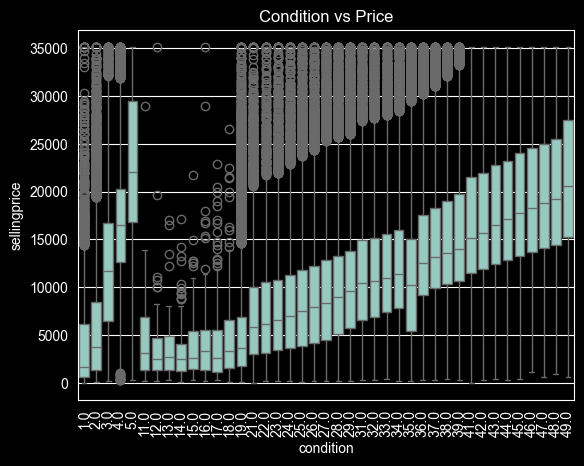

In [22]:
import seaborn as sns

sns.boxplot(x=df['condition'], y=df['sellingprice'])
plt.xticks(rotation=90)
plt.title("Condition vs Price")
plt.show()

## Top car brands

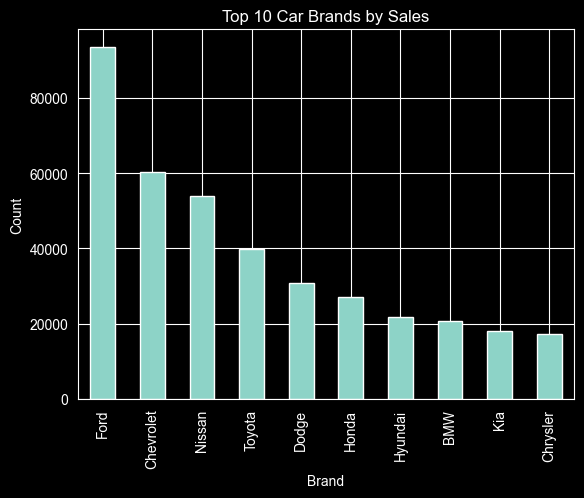

In [23]:
top_brands = df['make'].value_counts().head(10)

top_brands.plot(kind='bar')
plt.title("Top 10 Car Brands by Sales")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

## mmr vs selling price

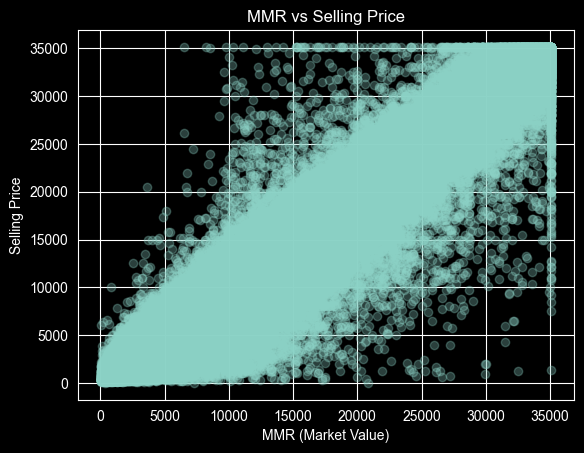

In [24]:
plt.scatter(df['mmr'], df['sellingprice'], alpha=0.3)
plt.xlabel("MMR (Market Value)")
plt.ylabel("Selling Price")
plt.title("MMR vs Selling Price")
plt.show()

In [17]:
df['price_diff'] = df['sellingprice'] - df['mmr']

In [18]:
df["price_diff"].describe()

count    558731.000000
mean       -157.831898
std        1758.207744
min      -87750.000000
25%        -800.000000
50%         -50.000000
75%         650.000000
max      207200.000000
Name: price_diff, dtype: float64

In [19]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"{column} -> Lower: {lower}, Upper: {upper}")

    df[column] = df[column].clip(lower, upper)
    return df

In [20]:
df = cap_outliers(df, 'sellingprice')
df = cap_outliers(df, 'odometer')
df = cap_outliers(df, 'mmr')

sellingprice -> Lower: -10050.0, Upper: 35150.0
odometer -> Lower: -77739.5, Upper: 205220.5
mmr -> Lower: -9700.0, Upper: 35100.0
